## `Mental Health Sentiment Analysis`

In [22]:
import pandas as pd 
from functions import DataCheck
import matplotlib.pyplot as plt 
import nltk
import string
import pickle as pkl
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the data
data = pd.read_csv('mental_health_data/Combined Data.csv', index_col=0)
data.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
# Shape of data
data.shape

(53043, 2)

`Data Cleaning`

In [4]:
data_check = DataCheck(data)

# Missing data
data_check.miss_data()
print("---------------")

# Duplicated records
data_check.dup_data()

Missing data:  statement    362
status         0
dtype: int64
---------------
Duplicates:  1944


In [5]:
# Drop the missing records
data.dropna(inplace=True)

# Drop duplicated records
data.drop_duplicates(inplace=True)

`1. Lower Text`

In [6]:
# Create cleaning set of the text column
data['clean_text'] = data['statement'].apply(lambda x: x.lower())
data.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,"trouble sleeping, confused mind, restless hear..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"all wrong, back off dear, forward doubt. stay ..."
3,I've shifted my focus to something else but I'...,Anxiety,i've shifted my focus to something else but i'...
4,"I'm restless and restless, it's been a month n...",Anxiety,"i'm restless and restless, it's been a month n..."


`2. Remove punctuations`

In [7]:
punc = string.punctuation
data['clean_text'] = data['clean_text'].apply(lambda x: x.translate(str.maketrans('', '', punc)))
data.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,all wrong back off dear forward doubt stay in ...
3,I've shifted my focus to something else but I'...,Anxiety,ive shifted my focus to something else but im ...
4,"I'm restless and restless, it's been a month n...",Anxiety,im restless and restless its been a month now ...


`3. Tokenize`

In [8]:
data['clean_text'] = data['clean_text'].apply(lambda x: word_tokenize(x))
data.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,"[oh, my, gosh]"
1,"trouble sleeping, confused mind, restless hear...",Anxiety,"[trouble, sleeping, confused, mind, restless, ..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"[all, wrong, back, off, dear, forward, doubt, ..."
3,I've shifted my focus to something else but I'...,Anxiety,"[ive, shifted, my, focus, to, something, else,..."
4,"I'm restless and restless, it's been a month n...",Anxiety,"[im, restless, and, restless, its, been, a, mo..."


`4. Handling stopwords`

In [9]:
stp_words = set(stopwords.words('english'))
data['clean_text'] = data['clean_text'].apply(lambda x: [word for word in x if word not in stp_words])
data.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,"[oh, gosh]"
1,"trouble sleeping, confused mind, restless hear...",Anxiety,"[trouble, sleeping, confused, mind, restless, ..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"[wrong, back, dear, forward, doubt, stay, rest..."
3,I've shifted my focus to something else but I'...,Anxiety,"[ive, shifted, focus, something, else, im, sti..."
4,"I'm restless and restless, it's been a month n...",Anxiety,"[im, restless, restless, month, boy, mean]"


`5. Lemmatization`

In [10]:
data['clean_text'] = data['clean_text'].apply(lambda x: [WordNetLemmatizer().lemmatize(word) for word in x])
data.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,"[oh, gosh]"
1,"trouble sleeping, confused mind, restless hear...",Anxiety,"[trouble, sleeping, confused, mind, restless, ..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"[wrong, back, dear, forward, doubt, stay, rest..."
3,I've shifted my focus to something else but I'...,Anxiety,"[ive, shifted, focus, something, else, im, sti..."
4,"I'm restless and restless, it's been a month n...",Anxiety,"[im, restless, restless, month, boy, mean]"


`6. Join Tokens`

In [11]:
data['clean_text'] = [" ".join(token) for token in data['clean_text']]
data.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,oh gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,Anxiety,ive shifted focus something else im still worried
4,"I'm restless and restless, it's been a month n...",Anxiety,im restless restless month boy mean


`7. Label Encoding`

In [12]:
encoder = LabelEncoder()
data['target_enc'] = encoder.fit_transform(data['status'])
data.head()

,statement,status,clean_text,target_enc
0,oh my gosh,Anxiety,oh gosh,0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...,0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...,0
3,I've shifted my focus to something else but I'...,Anxiety,ive shifted focus something else im still worried,0
4,"I'm restless and restless, it's been a month n...",Anxiety,im restless restless month boy mean,0


`Preprocessing  `

In [13]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['clean_text'])
y = data['target_enc']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42)

`Modelling`

Training Accuracy: 0.5581053970739346
Training Precision: 0.7694139835623983
-----------------------------
Testing Accuracy: 0.5064096291222233
Testing Precision: 0.6836921925165877


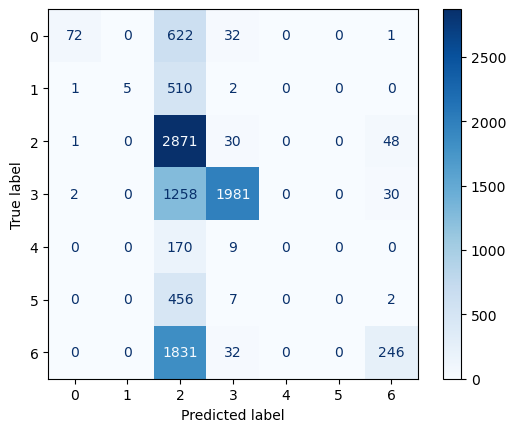

In [14]:
def classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    # Metrics
    train_preds = model.predict(X_train)
    print("Training Accuracy:", accuracy_score(y_train, train_preds))
    print("Training Precision:", precision_score(y_train, train_preds, average='weighted'))
    print("-----------------------------")

    test_preds = model.predict(X_test)
    print("Testing Accuracy:", accuracy_score(y_test, test_preds))
    print("Testing Precision:", precision_score(y_test, test_preds, average='weighted'))
    cm = confusion_matrix(y_test, test_preds)
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    display.plot(cmap=plt.cm.Blues)

classifier(MultinomialNB(), X_train, y_train, X_test, y_test)

Training Accuracy: 0.8262954445368694
Training Precision: 0.8275267238590782
-----------------------------
Testing Accuracy: 0.7446912613758685
Testing Precision: 0.7422377875740142


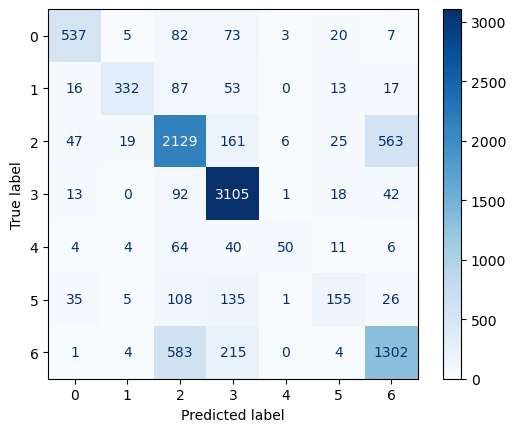

In [ ]:
# Logistic Regression
classifier(LogisticRegression(max_iter=1000), X_train, y_train, X_test, y_test)

Training Accuracy: 0.3308460145813965
Training Precision: 0.6816435938478275
-----------------------------
Testing Accuracy: 0.33114786182601036
Testing Precision: 0.5685320208952377


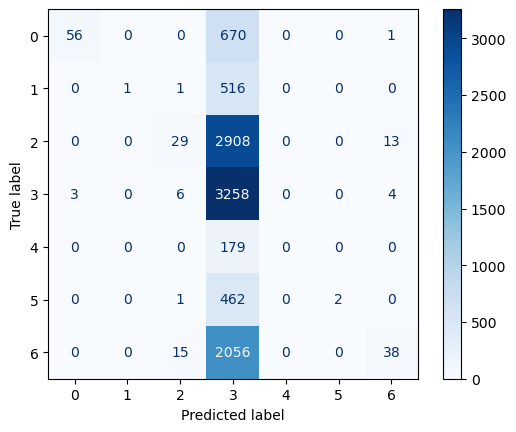

In [17]:
# K-Nearest Neighbors
classifier(KNeighborsClassifier(n_neighbors=5), X_train, y_train, X_test, y_test)

Training Accuracy: 0.9991192445075109
Training Precision: 0.9991202286702378
-----------------------------
Testing Accuracy: 0.6330365006360701
Testing Precision: 0.6265447081994204


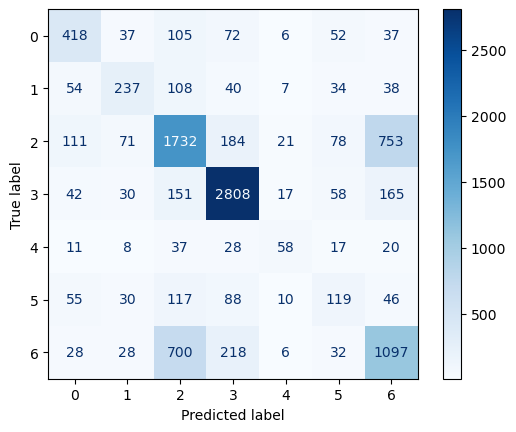

In [19]:
# Decision Tree
classifier(DecisionTreeClassifier(), X_train, y_train, X_test, y_test)

Training Accuracy: 0.9991192445075109
Training Precision: 0.9991195595429287
-----------------------------
Testing Accuracy: 0.6575007339269987
Testing Precision: 0.7138161702160811


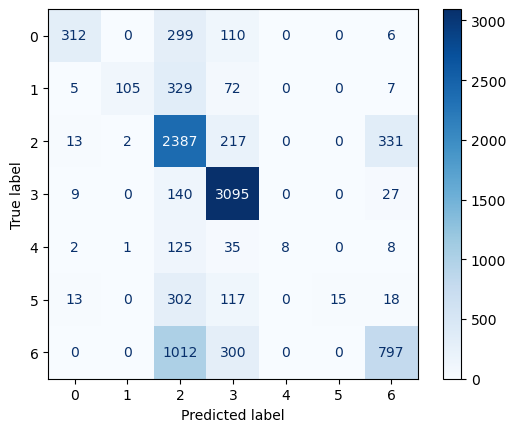

In [20]:
# Random Forest
classifier(RandomForestClassifier(n_estimators=100), X_train, y_train, X_test, y_test)

In [23]:
# Final model ~ Logistic regression
my_model = LogisticRegression(max_iter=1000)
my_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
# Save Model
with open('my_model.pkl', 'wb') as f:
    pkl.dump(my_model, f)

In [25]:
# Save the vectorizer
with open('vectorizer.pkl', 'wb') as f:
    pkl.dump(vectorizer, f)

`Predictions`

In [26]:
def predict_statement(statement):
    # Load the model and vectorizer
    with open('my_model.pkl', 'rb') as f:
        model = pkl.load(f)
    with open('vectorizer.pkl', 'rb') as f:
        vectorizer = pkl.load(f)

    # Preprocess the statement
    statement = statement.lower()
    statement = statement.translate(str.maketrans('', '', string.punctuation))
    statement = word_tokenize(statement)
    statement = [word for word in statement if word not in set(stopwords.words('english'))]
    statement = [WordNetLemmatizer().lemmatize(word) for word in statement]
    statement = " ".join(statement)

    # Transform the statement using the vectorizer
    statement_vectorized = vectorizer.transform([statement])

    # Make prediction
    prediction = model.predict(statement_vectorized)
    
    # Decode the prediction back to original label
    decoded_prediction = encoder.inverse_transform(prediction)
    
    return decoded_prediction[0]

In [ ]:
# Test1
predict_statement("I feel anxious and stressed about my exams.")

'Stress'

In [30]:
# Test2
predict_statement("I have been feeling very down and hopeless lately.")

'Depression'

In [34]:
data.status.value_counts()

status
Normal                  16040
Depression              15094
Suicidal                10644
Anxiety                  3623
Bipolar                  2501
Stress                   2296
Personality disorder      895
Name: count, dtype: int64

In [32]:
# Test3
predict_statement("Sometimes I feel happy and sometimes I feel sad, and then I feel anxious and stressed. All this at the same time")

'Depression'

In [44]:
# Test4
predict_statement("I feel amazing")

'Normal'